In [28]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
with open("benchmark_results_delays.json", "r") as f:
    results = json.load(f)

In [34]:
def parse_architecture(run_name):
    if run_name.lower().startswith("mlp"): return "MLP"
    elif run_name.lower().startswith("recurrent"): return "Recurrent"
    elif run_name.lower().startswith("modular"): return "Modular"
    elif run_name.lower().startswith("nervenet"): return "Modular"
    else: return "Unknown"

In [35]:
import re

def extract_delay(run_name):
    match = re.search(r'delay_(\d+)', run_name)
    return int(match.group(1)) if match else None

In [36]:
key_metrics = []
for k in results.keys():
    architecture = parse_architecture(k)
    delay = extract_delay(k)
    for dataset in ["train", "eval"]:
        key_metrics.append({
            "run_name": k,
            "dataset": dataset,
            "architecture": architecture,
            "n_actor_params": results[k]["n_actor_params"],
            "delay": delay,
            **results[k][dataset]["aggregate"],
        })

/tmp/ipykernel_355835/2849894687.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), frameon=False)
/tmp/ipykernel_355835/2849894687.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), frameon=False)
/tmp/ipykernel_355835/2849894687.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), frameon=False)
/tmp/ipykernel_355835/2849894687.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.

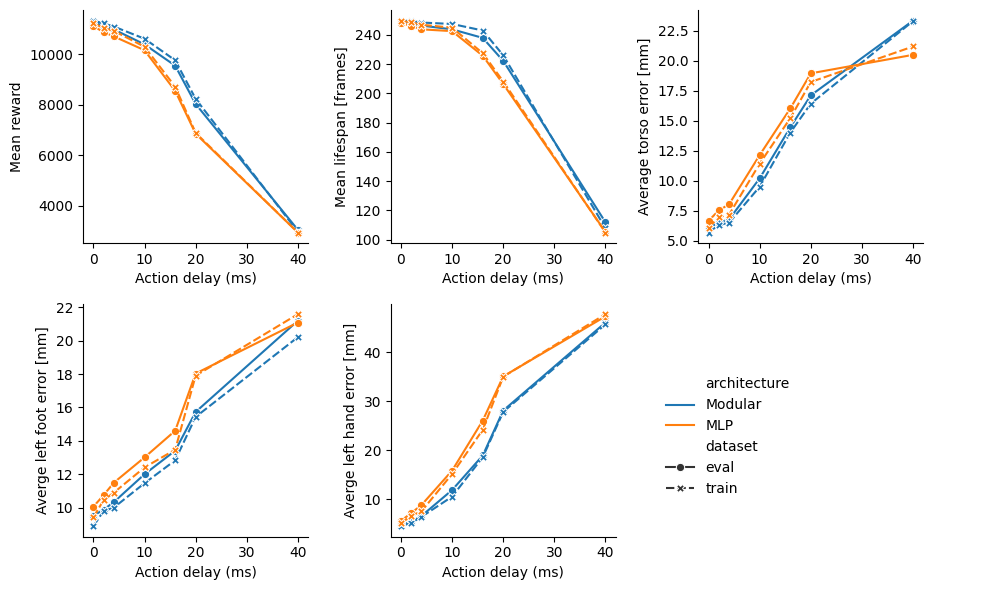

In [38]:
df = pd.DataFrame(key_metrics)
df["delay_ms"] = df.delay * 2 #ctrl_dt = 2ms
for c in df.columns:
    if c.endswith("_m"):
        df[c+"m"] = df[c]*1000 #m to mm conversion
metrics = {"mean_episode_reward": "Mean reward",
           "mean_lifespan": "Mean lifespan [frames]",
           "mean_root_pos_err_mm": "Average torso error [mm]",
           "mean_foot_L_pos_err_mm": "Averge left foot error [mm]",
           "mean_hand_L_pos_err_mm": "Averge left hand error [mm]"}
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
for ax, metric in zip(axs.flat, metrics.keys()):
    plt.sca(ax)
    legend = metric == "mean_hand_L_pos_err_mm"
    sns.lineplot(data=df, x="delay_ms", y=metric, hue="architecture", style="dataset", markers=True, style_order=["eval", "train"], legend=legend)
    plt.legend(loc=(1.2, 0.15), frameon=False)
    #plt.xscale('log')
    plt.xlabel("Action delay (ms)")
    plt.ylabel(metrics[metric])
    #plt.xticks([1e4, 1e5, 1e6, 1e7], ["10K", "100K", "1M", "10M"])
    sns.despine()
axs.flat[-1].axis("off")
plt.tight_layout(w_pad=-7)
plt.savefig("nervenet_vs_mlp_with_delays.svg")
plt.show()

In [19]:
df

,run_name,dataset,architecture,n_actor_params,delay,n_clips,mean_episode_reward,mean_lifespan,mean_hand_L_pos_err_m,mean_foot_L_pos_err_m,mean_root_pos_err_m,mean_appendages_pos_err_m,mean_hand_L_pos_err_mm,mean_foot_L_pos_err_mm,mean_root_pos_err_mm,mean_appendages_pos_err_mm
0,Modular_delay_0-20260506-103811,train,Modular,1426504,0,673,11320.628974,249.747400,0.004507,0.008889,0.005664,0.006718,4.506893,8.889000,5.663805,6.718157
1,Modular_delay_0-20260506-103811,eval,Modular,1426504,0,169,11246.366679,248.875740,0.004806,0.009495,0.006036,0.006956,4.805914,9.494659,6.036126,6.956041
2,Modular_delay_1-20260506-103008,train,Modular,1426504,1,673,11210.228549,249.511144,0.005151,0.009803,0.006304,0.007585,5.151002,9.803292,6.304214,7.585410
3,Modular_delay_1-20260506-103008,eval,Modular,1426504,1,169,11118.456526,247.639053,0.005376,0.009886,0.006498,0.007670,5.376102,9.886123,6.497790,7.669895
4,Modular_delay_2-20260507-042133,train,Modular,1426504,2,673,11084.840469,248.413076,0.006398,0.010004,0.006472,0.008121,6.397690,10.003843,6.471849,8.121290
5,Modular_delay_2-20260507-042133,eval,Modular,1426504,2,169,10971.253681,246.343195,0.006569,0.010327,0.006750,0.008303,6.568633,10.327059,6.749905,8.302761
6,Modular_delay_5-20260506-102359,train,Modular,1426504,5,673,10605.407688,247.442793,0.010521,0.011460,0.009481,0.011565,10.521313,11.459679,9.480691,11.564750
7,Modular_delay_5-20260506-102359,eval,Modular,1426504,5,169,10383.075779,243.763314,0.011858,0.011993,0.010178,0.012313,11.858156,11.992601,10.178376,12.312845
8,Modular_delay_20-20260506-103538,train,Modular,1426504,20,673,2978.590587,107.754829,0.045660,0.020191,0.023271,0.035356,45.660357,20.191356,23.270775,35.356109
9,Modular_delay_20-20260506-103538,eval,Modular,1426504,20,169,3055.296993,111.798817,0.046061,0.021194,0.023335,0.035376,46.061031,21.193969,23.334860,35.376248


/tmp/ipykernel_39949/1010813249.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), frameon=False)
/tmp/ipykernel_39949/1010813249.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), frameon=False)


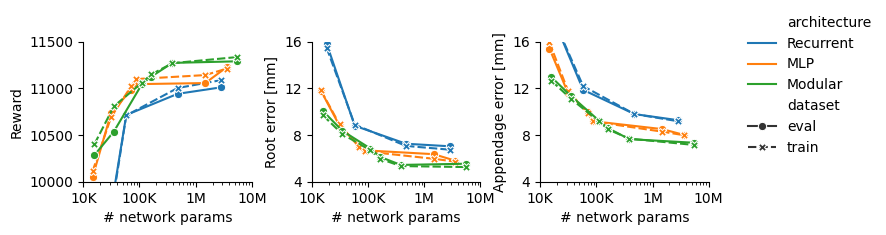

In [9]:
df = pd.DataFrame(key_metrics)
#df = df[df.architecture != "Recurrent"]
df = df[df.n_actor_params < 1e7]
for c in df.columns:
    if c.endswith("_m"):
        df[c+"m"] = df[c]*1000 #m to mm conversion
metrics = {"mean_episode_reward": "Reward",
           "mean_root_pos_err_mm": "Root error [mm]",
           "mean_appendages_pos_err_mm": "Appendage error [mm]"}
fig, axs = plt.subplots(1, 3, figsize=(8, 1.6))
for ax, metric in zip(axs.flat, metrics.keys()):
    plt.sca(ax)
    legend = metric == "mean_appendages_pos_err_mm"
    sns.lineplot(data=df, x="n_actor_params", y=metric, hue="architecture", style="dataset", markers=True, style_order=["eval", "train"], legend=legend)
    plt.legend(loc=(1.2, 0.15), frameon=False)
    plt.xscale('log')
    plt.xlabel("# network params")
    plt.ylabel(metrics[metric])
    plt.xticks([1e4, 1e5, 1e6, 1e7], ["10K", "100K", "1M", "10M"])
    sns.despine()
axs[0].set_ylim(10000, 11500)
for ax in axs[1:3]:
    ax.set_ylim(4, 16)
    ax.set_yticks([4,8,12,16])
#axs.flat[-1].axis("off")
plt.tight_layout(pad=-2.5)
plt.savefig("architecture_end_performance_comparison.svg", bbox_inches="tight")
plt.show()

In [10]:
with open("benchmark_training_curves.json", "r") as f:
    training_results = json.load(f)

In [12]:
for k in training_results:
    print(k, " ", training_results[k]["n_actor_params"])

Recurrent-20260416-163835   476808
MLPModular-20260318-113105   87112
Imitation_detached_critic_v4-20260319-155439   385608


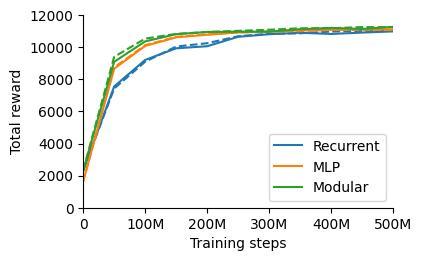

In [29]:
plt.figure(figsize=(4, 2.5))
for i, k in enumerate(training_results):
    x = training_results[k]["steps"]
    y_train = training_results[k]["train"]["mean_episode_reward"]
    y_eval = training_results[k]["eval"]["mean_episode_reward"]
    plt.plot(x, y_train, color=f"C{i}",  ls="--")
    plt.plot(x, y_eval, label=parse_architecture(k))
plt.xticks(1e8*np.arange(6), ["0"] + [f"{i}00M" for i in range(1, 6)])
plt.legend()
plt.xlabel("Training steps")
plt.ylabel("Total reward")
plt.ylim(0, 12000)
plt.xlim(0, 5e8)
sns.despine()
plt.savefig("architecture_training_speed_comparison.svg", bbox_inches="tight")
plt.show()